In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/house_prices.csv")

In [3]:
df[["Amount(in rupees)", "Price (in rupees)"]].head()

,Amount(in rupees),Price (in rupees)
0,42 Lac,6000.0
1,98 Lac,13799.0
2,1.40 Cr,17500.0
3,25 Lac,NaN
4,1.60 Cr,18824.0


In [4]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [5]:
# 查看数据基本信息
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [6]:
# 查看统计信息
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [7]:
# 查看列名
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='object')

In [8]:
# 检查缺失值
df.isnull().sum()

Index                     0
Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [9]:
import matplotlib.pyplot as plt

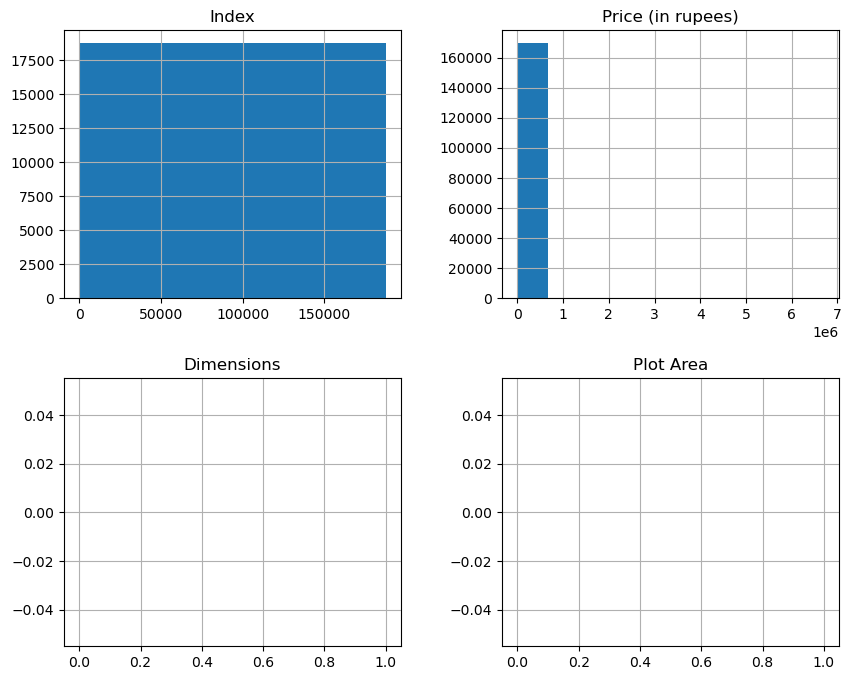

In [10]:
df.hist(figsize=(10,8))
plt.show()

In [11]:
df["Price (in rupees)"].describe()

count    1.698660e+05
mean     7.583772e+03
std      2.724171e+04
min      0.000000e+00
25%      4.297000e+03
50%      6.034000e+03
75%      9.450000e+03
max      6.700000e+06
Name: Price (in rupees), dtype: float64

In [12]:
# 公式 IQR = Q3 - Q1
# 异常范围 小于 Q1 - 1.5*IQR ，大于 Q3 + 1.5*IQR

In [13]:
Q1 = df["Price (in rupees)"].quantile(0.25)
Q3 = df["Price (in rupees)"].quantile(0.75)

IQR = Q3 - Q1

In [14]:
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [15]:
# 只保留正常房价范围内的数据，删除异常值
df = df[(df["Price (in rupees)"] >= lower) & (df["Price (in rupees)"] <= upper)]

In [16]:
df["Price (in rupees)"].describe()

count    161934.000000
mean       6672.622840
std        3120.985275
min           0.000000
25%        4222.000000
50%        5850.000000
75%        8333.000000
max       17179.000000
Name: Price (in rupees), dtype: float64

In [17]:
# 删除价格为0的数据
df = df[df["Price (in rupees)"] > 0]

In [18]:
df["Price (in rupees)"].describe()

count    161923.000000
mean       6673.076135
std        3120.606657
min           1.000000
25%        4222.000000
50%        5850.000000
75%        8333.000000
max       17179.000000
Name: Price (in rupees), dtype: float64

In [19]:
# 删除价格过于低的数据
df = df[df["Price (in rupees)"] > 1000]

In [20]:
df["Price (in rupees)"].describe()

count    161840.000000
mean       6676.306457
std        3118.138697
min        1047.000000
25%        4222.750000
50%        5857.000000
75%        8333.000000
max       17179.000000
Name: Price (in rupees), dtype: float64

In [21]:
# 删除无用字段
df = df.drop(columns=["Index","Title", "Description"])

# 查看Carpet Area数据

In [22]:
# 查看Carpet Area 数据
df["Carpet Area"].head()

0    500 sqft
1    473 sqft
5         NaN
6    550 sqft
7         NaN
Name: Carpet Area, dtype: object

In [23]:
# 查看Carpet Area 数据类型
df["Carpet Area"].dtype

dtype('O')

In [24]:
df["Carpet Area"].dropna().head(20)

0     500 sqft
1     473 sqft
6     550 sqft
9     900 sqft
10    950 sqft
15    675 sqft
16    647 sqft
18    600 sqft
20    430 sqft
21    665 sqft
22    557 sqft
23    870 sqft
26    288 sqft
28    925 sqft
29    434 sqft
31    850 sqft
32    467 sqft
33    849 sqft
34    440 sqft
38    639 sqft
Name: Carpet Area, dtype: object

# 提取面积数字

In [25]:
# 提取面积数字，将文本变为数字特征，并将字符串数字转为浮点数
df["Carpet Area"] = df["Carpet Area"].str.extract("(\d+)").astype(float)

In [26]:
df["Carpet Area"].head(10)

0     500.0
1     473.0
5       NaN
6     550.0
7       NaN
8       NaN
9     900.0
10    950.0
11      NaN
12      NaN
Name: Carpet Area, dtype: float64

In [27]:
# 类型变成float64证明面积已经成功变成数值
df["Carpet Area"].dtype

dtype('float64')

# 处理面积缺失值

In [28]:
# 查看缺失值
df["Carpet Area"].isnull().sum()

np.int64(74242)

In [29]:
# 使用中位数方法填补缺失值
df["Carpet Area"] = df["Carpet Area"].fillna(df["Carpet Area"].median())

In [30]:
df["Carpet Area"].isnull().sum()

np.int64(0)

# 处理分类变量

In [31]:
df.dtypes

Amount(in rupees)     object
Price (in rupees)    float64
location              object
Carpet Area          float64
Status                object
Floor                 object
Transaction           object
Furnishing            object
facing                object
overlooking           object
Society               object
Bathroom              object
Balcony               object
Car Parking           object
Ownership             object
Super Area            object
Dimensions           float64
Plot Area            float64
dtype: object

In [32]:
# 查看字符串变量的列
df.select_dtypes(include="object").columns

Index(['Amount(in rupees)', 'location', 'Status', 'Floor', 'Transaction',
       'Furnishing', 'facing', 'overlooking', 'Society', 'Bathroom', 'Balcony',
       'Car Parking', 'Ownership', 'Super Area'],
      dtype='object')

In [33]:
# 删除高基数列
df = df.drop(columns=[
    "Society",
    "Floor",
    "Super Area",
    "Amount(in rupees)",
    "Dimensions", 
    "Plot Area"
])

In [34]:
df.select_dtypes(include="object").columns

Index(['location', 'Status', 'Transaction', 'Furnishing', 'facing',
       'overlooking', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership'],
      dtype='object')

In [35]:
# 执行One-Hot Encoding，将类别变量拆成多个二进制（0或1）
df = pd.get_dummies(df, drop_first=True)

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 161840 entries, 0 to 187530
Columns: 336 entries, Price (in rupees) to Ownership_Power Of Attorney
dtypes: bool(334), float64(2)
memory usage: 55.3 MB


# 模型训练

In [37]:
from sklearn.model_selection import train_test_split

# 特征和目标变量
X = df.drop("Price (in rupees)", axis=1)
y = df["Price (in rupees)"]

In [38]:
# 划分数据
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("训练集:", X_train.shape)
print("测试集:", X_test.shape)

训练集: (129472, 335)
测试集: (32368, 335)


### 线性回归模型（Linear Regression）

In [39]:
X.isnull().sum().sum()

np.int64(0)

In [40]:
X.isnull().sum()[X.isnull().sum() > 0]

Series([], dtype: int64)

In [41]:
# 训练Linear Regression模型
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
# Linear Regression模型预测
y_pred_lr = lr.predict(X_test)

In [43]:
# 模型评估
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2:", r2_lr)

Linear Regression Results
MAE: 1629.7676311649127
RMSE: 2255.6715133576326
R2: 0.4802170672265015


### 决策树模型（Random Forest）

In [44]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    n_jobs=-1
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [45]:
y_pred_rf = rf.predict(X_test)

In [46]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2:", r2_rf)

Random Forest Results
MAE: 622.9307991279971
RMSE: 1308.2807885079847
R2: 0.8251473440687456


### XGBoost模型

In [47]:
!pip install xgboost

In [48]:
from xgboost import XGBRegressor

# 创建模型
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
)

# 训练模型
xgb.fit(X_train, y_train)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [49]:
y_pred_xgb = xgb.predict(X_test)

In [50]:
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

XGBoost Results
MAE: 875.8155272743576
RMSE: 1415.302361705967
R2: 0.7953702526125617


### 对比模型


In [51]:
print("Model Comparison")

print("Linear Regression:", r2_lr)
print("Random Forest:", r2_rf)
print("XGBoost:", r2)

Model Comparison
Linear Regression: 0.4802170672265015
Random Forest: 0.8251473440687456
XGBoost: 0.7953702526125617


## 解释模型（Feature Importance）

In [52]:
## Feature Importance Analysis
feature_importance = pd.Series(
    rf.feature_importances_,
    index = X.columns
).sort_values(ascending = False)

feature_importance.head(20) ##从最重要 → 最不重要 排序


Carpet Area               0.285310
location_new-delhi        0.083528
location_gurgaon          0.070671
Furnishing_Unfurnished    0.041173
facing_North - East       0.030430
overlooking_Pool          0.029931
Bathroom_3                0.028698
Car Parking_1 Covered,    0.027147
Balcony_2                 0.025428
location_bangalore        0.022319
Ownership_Freehold        0.021308
Transaction_Resale        0.019831
Balcony_4                 0.018041
location_thane            0.016916
location_mumbai           0.015700
facing_West               0.015595
Bathroom_2                0.014935
location_chennai          0.014250
Car Parking_2 Covered     0.013944
overlooking_Main Road     0.013015
dtype: float64

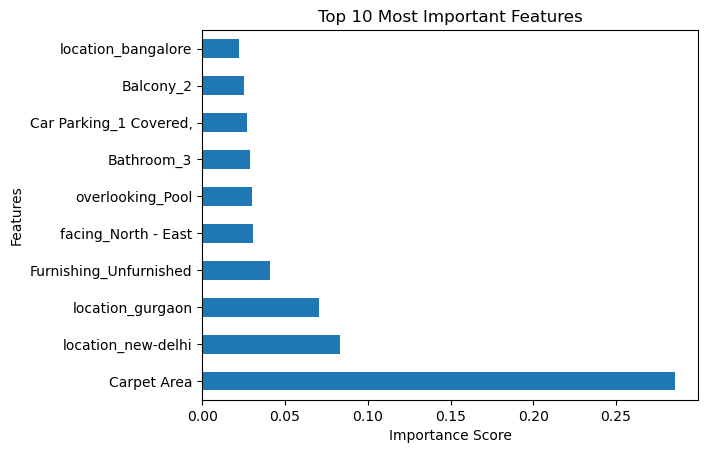

In [53]:
# 可视化重要特征
import matplotlib.pyplot as plt

feature_importance.head(10).plot(kind="barh")

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.savefig("../outputs/figures/feature_importance.png")

plt.show()

### 误差分析（Error Analysis）

In [54]:
# 真实价格 - 预测价格
errors = abs(y_test - y_pred_rf)

In [55]:
error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_rf,
    "Error": errors
})

In [56]:
error_df.sort_values("Error", ascending=False).head(10)

,Actual,Predicted,Error
114016,17045.0,4861.301598,12183.698402
41813,15842.0,4226.372526,11615.627474
176366,16235.0,5506.035014,10728.964986
118220,4461.0,15120.305000,10659.305000
40502,14727.0,4124.690000,10602.310000
93564,2750.0,13328.696145,10578.696145
91034,16734.0,6175.783106,10558.216894
93138,2833.0,13328.696145,10495.696145
91035,2927.0,13328.696145,10401.696145
143388,17105.0,6760.330153,10344.669847


In [57]:
worst_predictions = error_df.sort_values("Error", ascending=False).head(10)

X_test.loc[worst_predictions.index]

,Carpet Area,location_ahmadnagar,location_ahmedabad,location_allahabad,location_aurangabad,location_badlapur,location_bangalore,location_belgaum,location_bhiwadi,location_bhiwandi,...,Car Parking_9 Open,"Car Parking_90 Covered,",Car Parking_901 Covered,Car Parking_903 Covered,Car Parking_908 Covered,Car Parking_98 Covered,Car Parking_999 Covered,Ownership_Freehold,Ownership_Leasehold,Ownership_Power Of Attorney
114016,1050.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
41813,1050.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
176366,1050.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
118220,165.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
40502,1222.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
93564,1050.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
91034,1050.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
93138,1050.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
91035,1050.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
143388,1050.0,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False


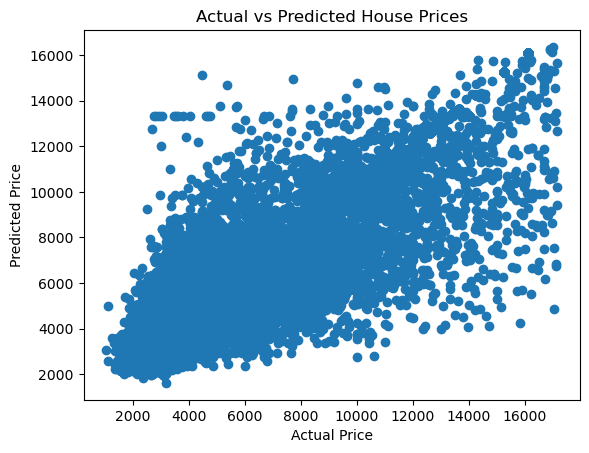

In [58]:
plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.savefig("../outputs/figures/ActualVSPredicted_HousePrice.png")

plt.show()

In [59]:
# 计算Random Forest 和 XGBoost 误差并比较
errors_rf = abs(y_test - y_pred_rf)
errors_xgb = abs(y_test - y_pred_xgb)

print(errors_rf.mean())
print(errors_xgb.mean())

622.9307991279971
875.8155272743576


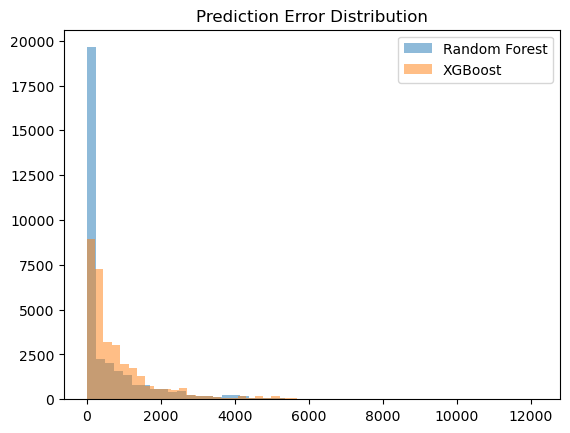

In [60]:
plt.hist(errors_rf, bins=50, alpha=0.5, label="Random Forest")
plt.hist(errors_xgb, bins=50, alpha=0.5, label="XGBoost")

plt.legend()
plt.title("Prediction Error Distribution")

plt.savefig("../outputs/figures/Prediction_Error_Distribution.png")

plt.show()

### 残差分析（Residual Analysis）

模型在哪些价格区间预测不好？
是否存在系统性偏差？
残差公式： Residual = Actual − Predicted
Error = |Actual − Predicted|
Residual = Actual − Predicted
Residual模型能告诉我们模型是高估还是低估。  

例如：
Actual = 8000
Predicted = 6000
Residual = 2000
模型低估  

Actual = 6000
Predicted = 8000
Residual = -2000
模型高估

In [61]:
residuals_rf = y_test - y_pred_rf

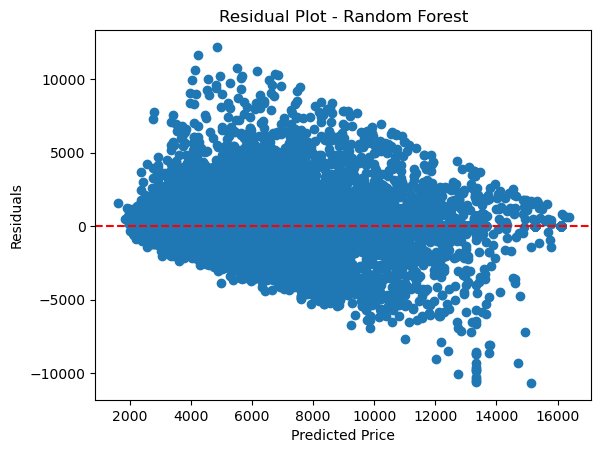

In [62]:
plt.scatter(y_pred_rf, residuals_rf)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot - Random Forest")

plt.savefig("../outputs/figures/residual_plot_rf.png")

plt.show()

## API

In [63]:
# 模型保存
import joblib

joblib.dump(rf, "../models/random_forest_model.pkl")

['../models/random_forest_model.pkl']

In [64]:
pip install fastapi uvicorn

Note: you may need to restart the kernel to use updated packages.


In [65]:
feature_columns = X_train.columns.tolist()

joblib.dump(feature_columns, "../models/feature_columns.pkl")

['../models/feature_columns.pkl']

## 构建Pieline


In [70]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor

# 构建Pipeline
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

# 训练
pipeline.fit(X_train, y_train)

,steps,"[('imputer', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,n_estimators,100


In [68]:
import joblib

joblib.dump(pipeline, "../models/house_price_pipeline.pkl")

['../models/house_price_pipeline.pkl']